# UTS Week 8 — End-to-End Machine Learning Challenge  
## Financial Risk (Classification): Credit Card Fraud Detection
1. Setup & Load Dataset  
2. EDA / Visualisasi Awal  
3. Handling Imbalance dengan SMOTE  
4. Training beberapa model  
5. Evaluasi, Confusion Matrix, dan Feature Importance  
6. Tracking eksperimen dengan W&B

## 0. Install Library
Jalankan sekali saja jika masih ada library yang belum terpasang.

In [1]:
# !pip install -q wandb imbalanced-learn xgboost openml

## 1. Import Library

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import wandb

## 2. Login W&B dan Konfigurasi
Kalau belum login, aktifkan `wandb.login()`.

In [3]:
# wandb.login()

WANDB_PROJECT = "uts-credit-card-fraud"
RANDOM_STATE = 42
SAMPLE_SIZE = 50000

## 3. Setup & Load Imbalanced Dataset
Dataset yang dipakai adalah **Credit Card Fraud** dari OpenML (ID: 1597).

In [4]:
print("Sedang mengambil dataset asli (imbalanced) dari OpenML...")
data = fetch_openml(data_id=1597, as_frame=True, parser="auto")

# Gabungkan fitur dan target
df = pd.concat([data.data, data.target], axis=1)
df.columns = [*df.columns[:-1], "Class"]
df["Class"] = df["Class"].astype(int)

# Ambil sampel 50.000 data agar runtime lebih ringan
df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

print(f"Dataset Berhasil Dimuat! Shape: {df.shape}")
print("\nProporsi Kelas Asli (SANGAT TIMPANG):")
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))
df.head()

Sedang mengambil dataset asli (imbalanced) dari OpenML...
Dataset Berhasil Dimuat! Shape: (50000, 30)

Proporsi Kelas Asli (SANGAT TIMPANG):
Class
0    49917
1       83
Name: count, dtype: int64
Class
0    0.99834
1    0.00166
Name: proportion, dtype: float64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


## 4. Analisis Data Awal (EDA)

In [5]:
print("Info dataset:")
df.info()

print("\nMissing values per kolom:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nStatistik deskriptif singkat:")
display(df.describe().T.head(10))

Info dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 43428 to 274591
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      50000 non-null  float64
 1   V2      50000 non-null  float64
 2   V3      50000 non-null  float64
 3   V4      50000 non-null  float64
 4   V5      50000 non-null  float64
 5   V6      50000 non-null  float64
 6   V7      50000 non-null  float64
 7   V8      50000 non-null  float64
 8   V9      50000 non-null  float64
 9   V10     50000 non-null  float64
 10  V11     50000 non-null  float64
 11  V12     50000 non-null  float64
 12  V13     50000 non-null  float64
 13  V14     50000 non-null  float64
 14  V15     50000 non-null  float64
 15  V16     50000 non-null  float64
 16  V17     50000 non-null  float64
 17  V18     50000 non-null  float64
 18  V19     50000 non-null  float64
 19  V20     50000 non-null  float64
 20  V21     50000 non-null  float64
 21  V22     50000 non-nul

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0



Statistik deskriptif singkat:


,count,mean,std,min,25%,50%,75%,max
V1,50000.0,-0.002393,1.960996,-34.148234,-0.920183,0.019063,1.318402,2.439207
V2,50000.0,0.000194,1.631727,-48.060856,-0.602984,0.064134,0.799725,21.467203
V3,50000.0,0.001736,1.524856,-33.680984,-0.893569,0.179505,1.034335,9.382558
V4,50000.0,0.002464,1.414847,-5.560118,-0.846430,-0.019294,0.742609,12.699542
V5,50000.0,0.002483,1.352321,-23.669726,-0.697761,-0.048754,0.618020,29.016124
V6,50000.0,0.001580,1.316629,-20.869626,-0.766752,-0.272763,0.407427,16.493227
V7,50000.0,-0.003289,1.207910,-41.506796,-0.559201,0.036088,0.571469,21.437514
V8,50000.0,0.000617,1.212368,-50.420090,-0.209881,0.021590,0.324369,19.168327
V9,50000.0,-0.002554,1.105842,-13.434066,-0.645955,-0.053654,0.592222,15.594995
V10,50000.0,0.008676,1.101552,-24.403185,-0.529439,-0.085910,0.467737,23.745136


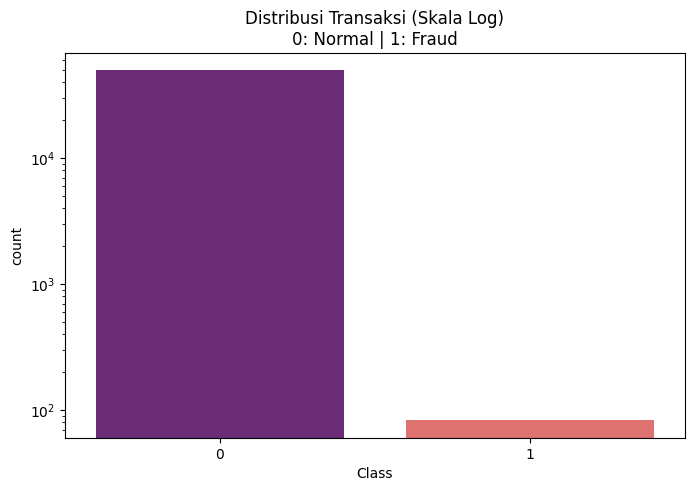

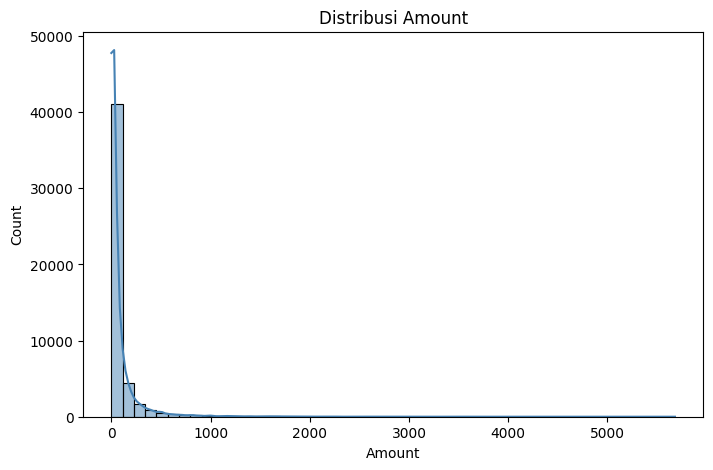

In [6]:
# Distribusi kelas
plt.figure(figsize=(8, 5))
sns.countplot(x="Class", data=df, palette="magma", hue="Class", legend=False)
plt.title("Distribusi Transaksi (Skala Log)\n0: Normal | 1: Fraud")
plt.yscale("log")
plt.show()

# Distribusi Amount
plt.figure(figsize=(8, 5))
sns.histplot(df["Amount"], bins=50, kde=True, color="steelblue")
plt.title("Distribusi Amount")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

## 5. Split Data
Gunakan `stratify=y` agar proporsi fraud tetap terjaga di train dan test.

In [7]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("\nDistribusi target pada data train:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi target pada data test:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (40000, 29)
Ukuran X_test : (10000, 29)

Distribusi target pada data train:
Class
0    0.99835
1    0.00165
Name: proportion, dtype: float64

Distribusi target pada data test:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


## 6. Handling Imbalance dengan SMOTE
SMOTE dilakukan **hanya pada data training**.

In [8]:
print("Menjalankan SMOTE untuk menyeimbangkan data...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Jumlah data setelah SMOTE:", len(y_train_smote))
print("\nProporsi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True))

Menjalankan SMOTE untuk menyeimbangkan data...
Jumlah data setelah SMOTE: 79868

Proporsi kelas setelah SMOTE:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64


## 7. Visualisasi Efek SMOTE

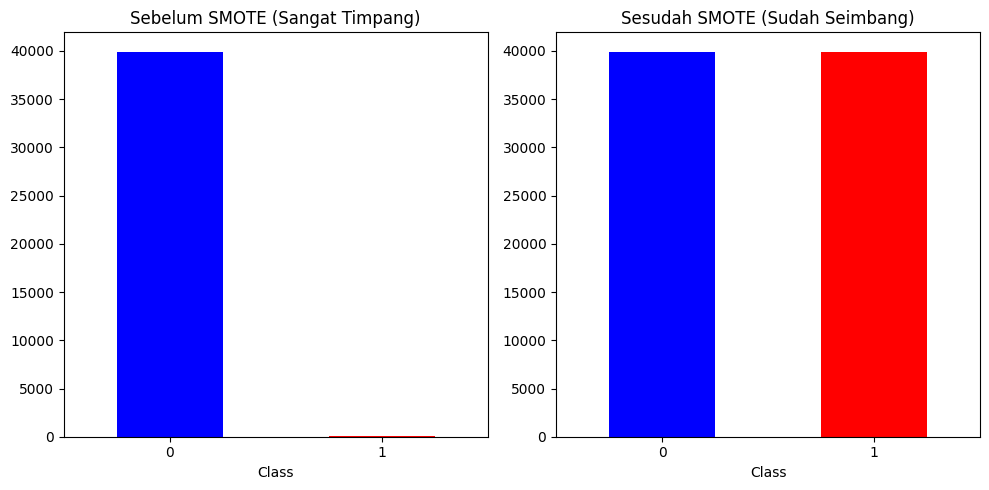

In [9]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Sebelum SMOTE (Sangat Timpang)")
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
pd.Series(y_train_smote).value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Sesudah SMOTE (Sudah Seimbang)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Eksperimen 1 — Logistic Regression + SMOTE
Model linear sebagai baseline sederhana.

In [10]:
run_lr = wandb.init(project=WANDB_PROJECT, name="logistic_regression_smote", reinit=True)

log_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train_smote, y_train_smote)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auprc_lr = average_precision_score(y_test, y_prob_lr)

wandb.log({
    "Accuracy": acc_lr,
    "Precision": prec_lr,
    "Recall": rec_lr,
    "F1_Score": f1_lr,
    "AUPRC": auprc_lr
})

print("--- HASIL EVALUASI LOGISTIC REGRESSION ---")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print(f"AUPRC    : {auprc_lr:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mushab-a-fathin (mushab-a-fathin-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


--- HASIL EVALUASI LOGISTIC REGRESSION ---
Accuracy : 0.9831
Precision: 0.0730
Recall   : 0.7647
F1-Score : 0.1333
AUPRC    : 0.6698

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9983
           1       0.07      0.76      0.13        17

    accuracy                           0.98     10000
   macro avg       0.54      0.87      0.56     10000
weighted avg       1.00      0.98      0.99     10000



## 9. Confusion Matrix — Logistic Regression

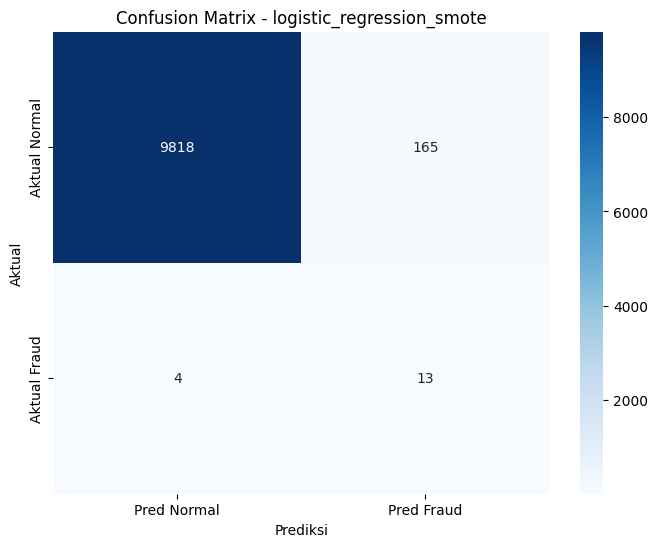

AUPRC,▁
Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
AUPRC,0.66977
Accuracy,0.9831
F1_Score,0.13333
Precision,0.07303
Recall,0.76471


In [11]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig_lr, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_lr, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Fraud"],
    yticklabels=["Aktual Normal", "Aktual Fraud"],
    ax=ax
)
ax.set_title("Confusion Matrix - logistic_regression_smote")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.show()

wandb.log({"confusion_matrix": wandb.Image(fig_lr)})
wandb.finish()

## 10. Eksperimen 2 — Random Forest + SMOTE
Model Bagging / tree-based.

In [12]:
run_rf = wandb.init(project=WANDB_PROJECT, name="random_forest_smote", reinit=True)

rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auprc_rf = average_precision_score(y_test, y_prob_rf)

wandb.log({
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1_Score": f1_rf,
    "AUPRC": auprc_rf
})

print("--- HASIL EVALUASI RANDOM FOREST ---")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"AUPRC    : {auprc_rf:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

--- HASIL EVALUASI RANDOM FOREST ---
Accuracy : 0.9993
Precision: 0.8571
Recall   : 0.7059
F1-Score : 0.7742
AUPRC    : 0.6656

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.86      0.71      0.77        17

    accuracy                           1.00     10000
   macro avg       0.93      0.85      0.89     10000
weighted avg       1.00      1.00      1.00     10000



## 11. Confusion Matrix — Random Forest

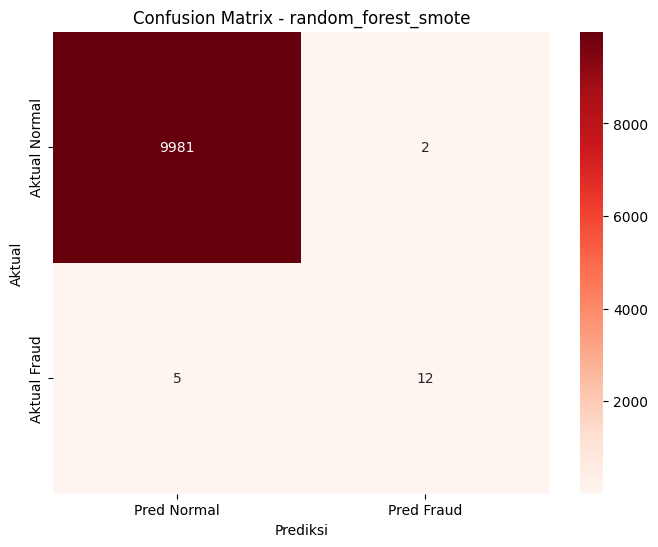

AUPRC,▁
Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
AUPRC,0.66558
Accuracy,0.9993
F1_Score,0.77419
Precision,0.85714
Recall,0.70588


In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig_rf, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Reds",
    xticklabels=["Pred Normal", "Pred Fraud"],
    yticklabels=["Aktual Normal", "Aktual Fraud"],
    ax=ax
)
ax.set_title("Confusion Matrix - random_forest_smote")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.show()

wandb.log({"confusion_matrix": wandb.Image(fig_rf)})
wandb.finish()

## 12. Eksperimen 3 — XGBoost + SMOTE
Model Ensemble Boosting.

In [14]:
run_xgb = wandb.init(project=WANDB_PROJECT, name="xgboost_smote", reinit=True)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auprc_xgb = average_precision_score(y_test, y_prob_xgb)

wandb.log({
    "Accuracy": acc_xgb,
    "Precision": prec_xgb,
    "Recall": rec_xgb,
    "F1_Score": f1_xgb,
    "AUPRC": auprc_xgb
})

print("--- HASIL EVALUASI XGBOOST ---")
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"AUPRC    : {auprc_xgb:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

--- HASIL EVALUASI XGBOOST ---
Accuracy : 0.9991
Precision: 0.7222
Recall   : 0.7647
F1-Score : 0.7429
AUPRC    : 0.7222

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.72      0.76      0.74        17

    accuracy                           1.00     10000
   macro avg       0.86      0.88      0.87     10000
weighted avg       1.00      1.00      1.00     10000



## 13. Confusion Matrix — XGBoost

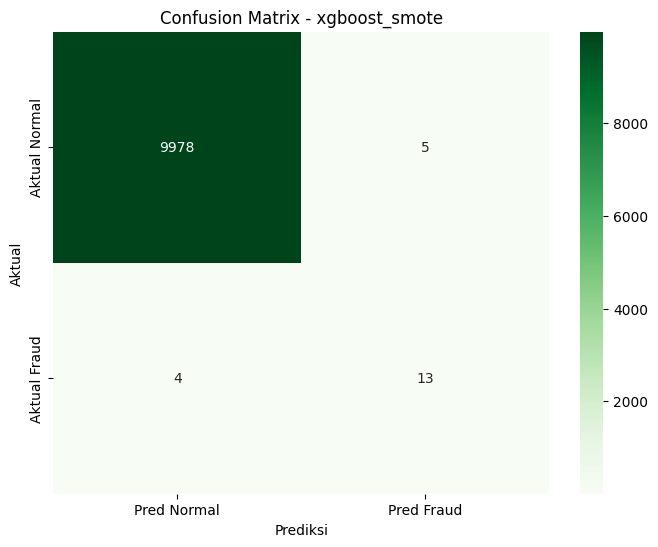

AUPRC,▁
Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
AUPRC,0.72219
Accuracy,0.9991
F1_Score,0.74286
Precision,0.72222
Recall,0.76471


In [15]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig_xgb, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_xgb, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred Normal", "Pred Fraud"],
    yticklabels=["Aktual Normal", "Aktual Fraud"],
    ax=ax
)
ax.set_title("Confusion Matrix - xgboost_smote")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.show()

wandb.log({"confusion_matrix": wandb.Image(fig_xgb)})
wandb.finish()

## 14. Perbandingan Hasil 3 Model

In [16]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": acc_lr,
        "AUPRC": auprc_lr,
        "Recall": rec_lr,
        "Precision": prec_lr,
        "F1_Score": f1_lr
    },
    {
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "AUPRC": auprc_rf,
        "Recall": rec_rf,
        "Precision": prec_rf,
        "F1_Score": f1_rf
    },
    {
        "Model": "XGBoost",
        "Accuracy": acc_xgb,
        "AUPRC": auprc_xgb,
        "Recall": rec_xgb,
        "Precision": prec_xgb,
        "F1_Score": f1_xgb
    }
])

results_df = results_df.sort_values(by=["AUPRC", "Recall"], ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,AUPRC,Recall,Precision,F1_Score
0,XGBoost,0.9991,0.722185,0.764706,0.722222,0.742857
1,Logistic Regression,0.9831,0.669766,0.764706,0.073034,0.133333
2,Random Forest,0.9993,0.665581,0.705882,0.857143,0.774194


## 15. Analisis Confusion Matrix Model Terbaik
Untuk kasus fraud, model terbaik dipilih berdasarkan **AUPRC** dan **Recall**.

In [17]:
best_model_name = results_df.loc[0, "Model"]
print("Model terbaik berdasarkan AUPRC dan Recall:", best_model_name)

if best_model_name == "Logistic Regression":
    best_cm = cm_lr
elif best_model_name == "Random Forest":
    best_cm = cm_rf
else:
    best_cm = cm_xgb

tn, fp, fn, tp = best_cm.ravel()

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

Model terbaik berdasarkan AUPRC dan Recall: XGBoost
TN = 9978
FP = 5
FN = 4
TP = 13


## 16. Feature Importance Model Terbaik

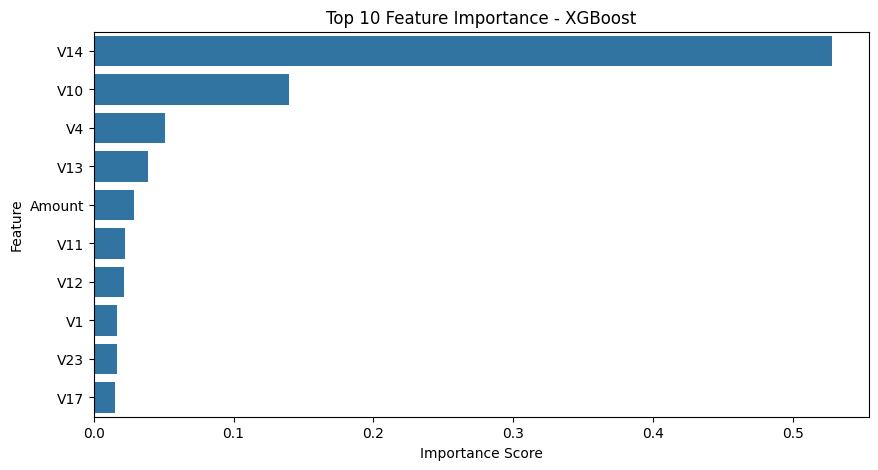

In [18]:
if best_model_name == "Logistic Regression":
    coef = pd.Series(log_reg.named_steps["clf"].coef_[0], index=X.columns)
    importance = coef.abs().sort_values(ascending=False).head(10)
    title = "Top 10 Feature Importance - Logistic Regression (abs coef)"
elif best_model_name == "Random Forest":
    importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    title = "Top 10 Feature Importance - Random Forest"
else:
    importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    title = "Top 10 Feature Importance - XGBoost"

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index)
plt.title(title)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()